In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
from google.colab import files

uploaded = files.upload()

Saving ECommerce_Fraud_Detection_Dataset.csv to ECommerce_Fraud_Detection_Dataset.csv


In [7]:
df = pd.read_csv("/content/ECommerce_Fraud_Detection_Dataset.csv")

In [8]:
df.head()


,TransactionID,TransactionAmount,TransactionHour,PaymentMethod,DeviceType,Country,AccountAgeDays,FailedLoginAttempts,IPRiskScore,DistanceFromHomeKM,IsFraud
0,1,36.20,18,Credit Card,Mobile,UK,999,1,74,6.59,0
1,2,226.76,21,Credit Card,Desktop,USA,748,0,70,33.15,0
2,3,99.76,1,UPI,Mobile,India,1354,2,27,23.11,0
3,4,69.47,7,Debit Card,Mobile,UK,321,0,24,10.42,0
4,5,13.72,3,Net Banking,Mobile,USA,2113,0,26,1.47,0


In [9]:
df.shape

(150000, 11)

In [10]:
df.columns

Index(['TransactionID', 'TransactionAmount', 'TransactionHour',
       'PaymentMethod', 'DeviceType', 'Country', 'AccountAgeDays',
       'FailedLoginAttempts', 'IPRiskScore', 'DistanceFromHomeKM', 'IsFraud'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   TransactionID        150000 non-null  int64  
 1   TransactionAmount    150000 non-null  float64
 2   TransactionHour      150000 non-null  int64  
 3   PaymentMethod        150000 non-null  object 
 4   DeviceType           150000 non-null  object 
 5   Country              150000 non-null  object 
 6   AccountAgeDays       150000 non-null  int64  
 7   FailedLoginAttempts  150000 non-null  int64  
 8   IPRiskScore          150000 non-null  int64  
 9   DistanceFromHomeKM   150000 non-null  float64
 10  IsFraud              150000 non-null  int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 12.6+ MB


In [12]:
df.describe()

,TransactionID,TransactionAmount,TransactionHour,AccountAgeDays,FailedLoginAttempts,IPRiskScore,DistanceFromHomeKM,IsFraud
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,75000.500000,75.950085,11.494800,1828.575200,0.301493,50.390853,19.961492,0.062547
std,43301.414527,74.745126,6.923127,1053.921688,0.549906,28.858952,19.993756,0.242147
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,37500.750000,22.550000,5.000000,914.000000,0.000000,25.000000,5.740000,0.000000
50%,75000.500000,53.200000,11.000000,1835.000000,0.000000,50.000000,13.790000,0.000000
75%,112500.250000,105.080000,17.000000,2742.000000,1.000000,75.000000,27.640000,0.000000
max,150000.000000,881.600000,23.000000,3650.000000,5.000000,100.000000,260.370000,1.000000


In [13]:
df.isnull().sum()

,0
TransactionID,0
TransactionAmount,0
TransactionHour,0
PaymentMethod,0
DeviceType,0
Country,0
AccountAgeDays,0
FailedLoginAttempts,0
IPRiskScore,0
DistanceFromHomeKM,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.drop('TransactionID', axis=1, inplace=True)

df.head()

,TransactionAmount,TransactionHour,PaymentMethod,DeviceType,Country,AccountAgeDays,FailedLoginAttempts,IPRiskScore,DistanceFromHomeKM,IsFraud
0,36.20,18,Credit Card,Mobile,UK,999,1,74,6.59,0
1,226.76,21,Credit Card,Desktop,USA,748,0,70,33.15,0
2,99.76,1,UPI,Mobile,India,1354,2,27,23.11,0
3,69.47,7,Debit Card,Mobile,UK,321,0,24,10.42,0
4,13.72,3,Net Banking,Mobile,USA,2113,0,26,1.47,0


In [16]:
threshold = df['TransactionAmount'].quantile(0.75)

df['HighAmount'] = np.where(df['TransactionAmount'] >= threshold, 1, 0)

df[['TransactionAmount','HighAmount']].head()

,TransactionAmount,HighAmount
0,36.20,0
1,226.76,1
2,99.76,0
3,69.47,0
4,13.72,0


In [17]:
df['IsNightTransaction'] = np.where(
    (df['TransactionHour'] >= 22) |
    (df['TransactionHour'] <= 5),
    1,
    0
)

df[['TransactionHour','IsNightTransaction']].head()

,TransactionHour,IsNightTransaction
0,18,0
1,21,0
2,1,1
3,7,0
4,3,1


In [18]:
def ip_risk(score):

    if score < 30:
        return "Low"

    elif score < 70:
        return "Medium"

    else:
        return "High"

df['IPRiskLevel'] = df['IPRiskScore'].apply(ip_risk)

df[['IPRiskScore','IPRiskLevel']].head()

,IPRiskScore,IPRiskLevel
0,74,High
1,70,High
2,27,Low
3,24,Low
4,26,Low


In [19]:
def distance_category(distance):

    if distance < 20:
        return "Near"

    elif distance < 100:
        return "Medium"

    else:
        return "Far"

df['DistanceCategory'] = df['DistanceFromHomeKM'].apply(distance_category)

df[['DistanceFromHomeKM','DistanceCategory']].head()

,DistanceFromHomeKM,DistanceCategory
0,6.59,Near
1,33.15,Medium
2,23.11,Medium
3,10.42,Near
4,1.47,Near


In [20]:
def account_age(days):

    if days < 180:
        return "New"

    elif days < 730:
        return "Regular"

    else:
        return "Old"

df['AccountCategory'] = df['AccountAgeDays'].apply(account_age)

df[['AccountAgeDays','AccountCategory']].head()

,AccountAgeDays,AccountCategory
0,999,Old
1,748,Old
2,1354,Old
3,321,Regular
4,2113,Old


In [21]:
df.columns

Index(['TransactionAmount', 'TransactionHour', 'PaymentMethod', 'DeviceType',
       'Country', 'AccountAgeDays', 'FailedLoginAttempts', 'IPRiskScore',
       'DistanceFromHomeKM', 'IsFraud', 'HighAmount', 'IsNightTransaction',
       'IPRiskLevel', 'DistanceCategory', 'AccountCategory'],
      dtype='object')

In [22]:
df['LoginRisk'] = np.where(df['FailedLoginAttempts'] >= 3, 1, 0)

df[['FailedLoginAttempts','LoginRisk']].head()

,FailedLoginAttempts,LoginRisk
0,1,0
1,0,0
2,2,0
3,0,0
4,0,0


In [23]:
df['Amount_IPRisk'] = (
    df['TransactionAmount'] *
    df['IPRiskScore']
)

df[['TransactionAmount',
     'IPRiskScore',
     'Amount_IPRisk']].head()

,TransactionAmount,IPRiskScore,Amount_IPRisk
0,36.20,74,2678.80
1,226.76,70,15873.20
2,99.76,27,2693.52
3,69.47,24,1667.28
4,13.72,26,356.72


In [25]:
df.head()

,TransactionAmount,TransactionHour,PaymentMethod,DeviceType,Country,AccountAgeDays,FailedLoginAttempts,IPRiskScore,DistanceFromHomeKM,IsFraud,HighAmount,IsNightTransaction,IPRiskLevel,DistanceCategory,AccountCategory,LoginRisk,Amount_IPRisk
0,36.20,18,Credit Card,Mobile,UK,999,1,74,6.59,0,0,0,High,Near,Old,0,2678.80
1,226.76,21,Credit Card,Desktop,USA,748,0,70,33.15,0,1,0,High,Medium,Old,0,15873.20
2,99.76,1,UPI,Mobile,India,1354,2,27,23.11,0,0,1,Low,Medium,Old,0,2693.52
3,69.47,7,Debit Card,Mobile,UK,321,0,24,10.42,0,0,0,Low,Near,Regular,0,1667.28
4,13.72,3,Net Banking,Mobile,USA,2113,0,26,1.47,0,0,1,Low,Near,Old,0,356.72


In [26]:
df.shape

(150000, 17)

/tmp/ipykernel_1744/2655536554.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HighAmount', data=df, palette='viridis')


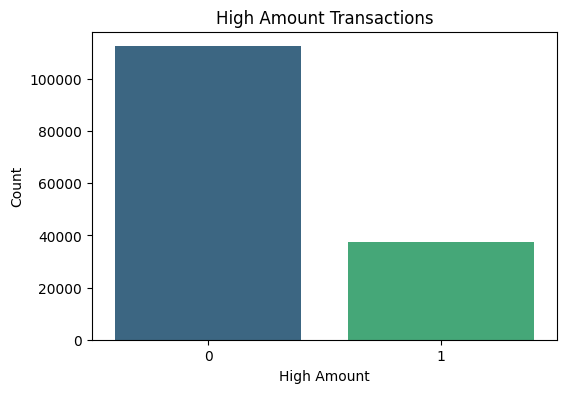

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(x='HighAmount', data=df, palette='viridis')

plt.title("High Amount Transactions")
plt.xlabel("High Amount")
plt.ylabel("Count")

plt.show()

/tmp/ipykernel_1744/4119362778.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsNightTransaction',


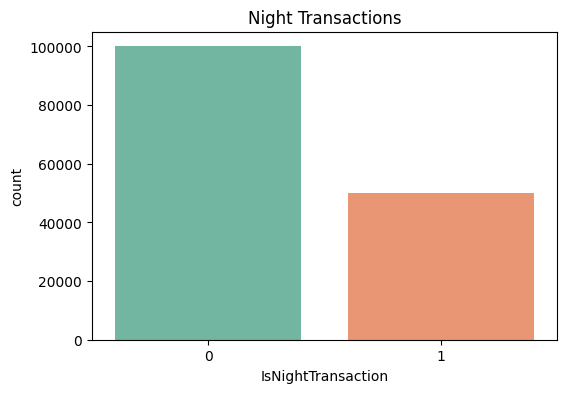

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(x='IsNightTransaction',
              data=df,
              palette='Set2')

plt.title("Night Transactions")
plt.show()

/tmp/ipykernel_1744/2184945651.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IPRiskLevel',


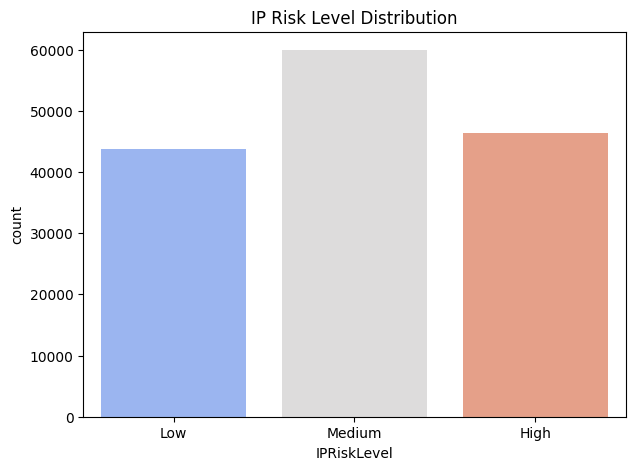

In [29]:
plt.figure(figsize=(7,5))

sns.countplot(x='IPRiskLevel',
              data=df,
              order=['Low','Medium','High'],
              palette='coolwarm')

plt.title("IP Risk Level Distribution")

plt.show()

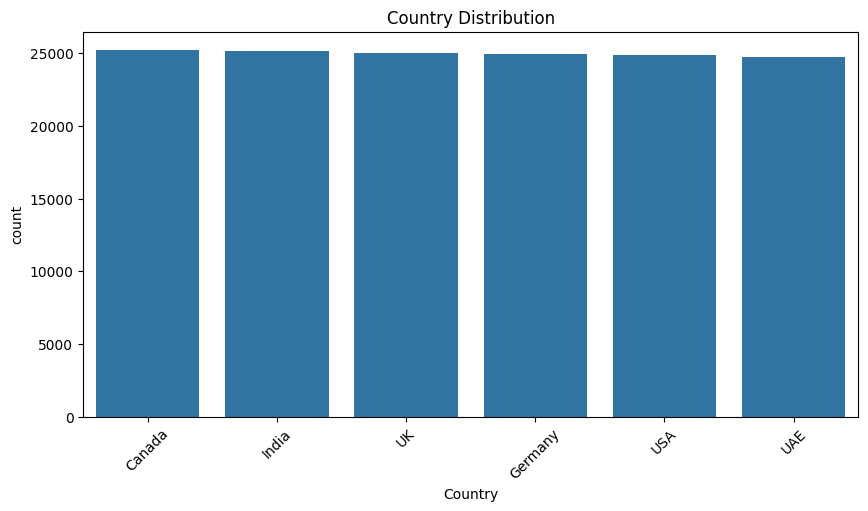

In [30]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Country',
    data=df,
    order=df['Country'].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Country Distribution")

plt.show()

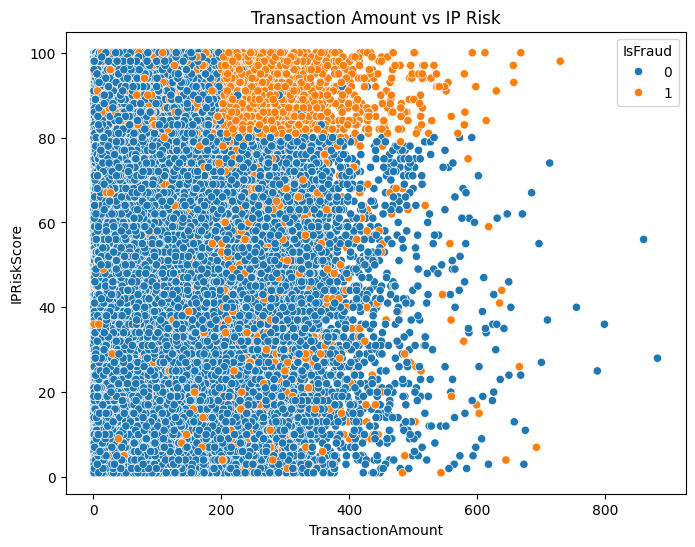

In [31]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='TransactionAmount',
    y='IPRiskScore',
    hue='IsFraud',
    data=df
)

plt.title("Transaction Amount vs IP Risk")

plt.show()

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    'PaymentMethod',
    'DeviceType',
    'Country',
    'DistanceCategory',
    'AccountCategory',
    'IPRiskLevel'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,TransactionAmount,TransactionHour,PaymentMethod,DeviceType,Country,AccountAgeDays,FailedLoginAttempts,IPRiskScore,DistanceFromHomeKM,IsFraud,HighAmount,IsNightTransaction,IPRiskLevel,DistanceCategory,AccountCategory,LoginRisk,Amount_IPRisk
0,36.20,18,0,1,4,999,1,74,6.59,0,0,0,0,2,1,0,2678.80
1,226.76,21,0,0,5,748,0,70,33.15,0,1,0,0,1,1,0,15873.20
2,99.76,1,3,1,2,1354,2,27,23.11,0,0,1,1,1,1,0,2693.52
3,69.47,7,1,1,4,321,0,24,10.42,0,0,0,1,2,2,0,1667.28
4,13.72,3,2,1,5,2113,0,26,1.47,0,0,1,1,2,1,0,356.72


In [33]:
X = df.drop("IsFraud", axis=1)
y = df["IsFraud"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (150000, 16)
Target Shape : (150000,)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (120000, 16)
Testing Data : (30000, 16)


In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

rf_model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [36]:
y_pred = rf_model.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy * 100,2), "%")



Accuracy : 96.91 %


In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     28124
           1       0.98      0.52      0.68      1876

    accuracy                           0.97     30000
   macro avg       0.97      0.76      0.83     30000
weighted avg       0.97      0.97      0.96     30000



In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[28101    23]
 [  903   973]]


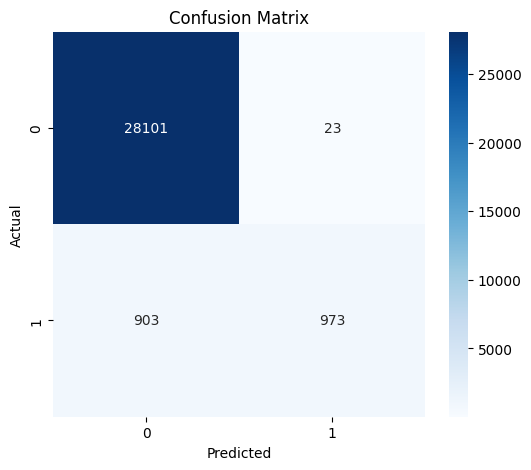

In [40]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [41]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
8,DistanceFromHomeKM,0.278227
7,IPRiskScore,0.243824
15,Amount_IPRisk,0.179078
0,TransactionAmount,0.158388
11,IPRiskLevel,0.058885
12,DistanceCategory,0.021673
9,HighAmount,0.015904
6,FailedLoginAttempts,0.011634
14,LoginRisk,0.009842
5,AccountAgeDays,0.008622


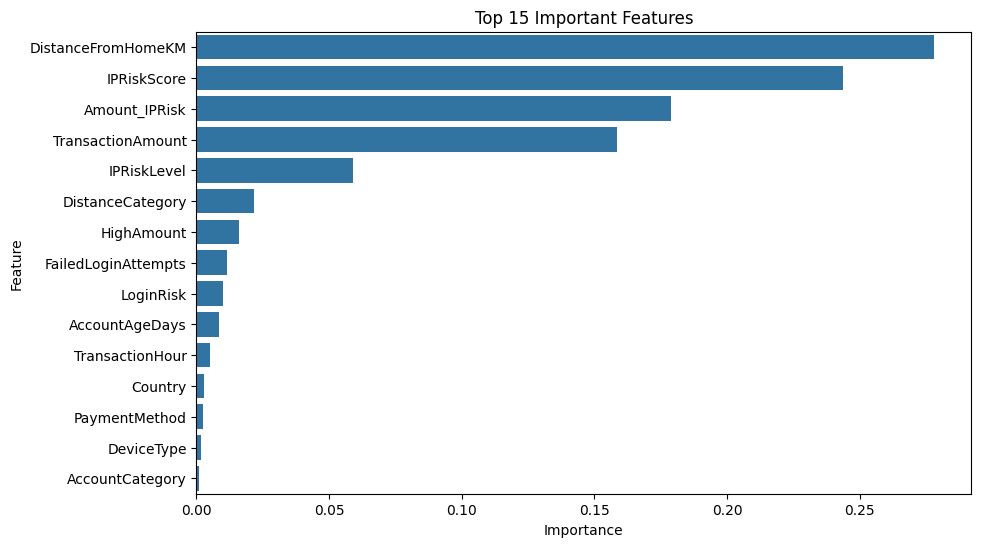

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

In [43]:
sample = pd.DataFrame({
    "TransactionAmount":[500],
    "TransactionHour":[23],
    "PaymentMethod":[1],
    "DeviceType":[1],
    "Country":[2],
    "AccountAgeDays":[200],
    "FailedLoginAttempts":[4],
    "IPRiskScore":[85],
    "DistanceFromHomeKM":[120],
    "HighAmount":[1],
    "IsNightTransaction":[1],
    "LoginRisk":[1],
    "DistanceCategory":[0],
    "AccountCategory":[1],
    "IPRiskLevel":[0],
    "Amount_IPRisk":[500*85] # Corrected column name
})

# Ensure the order of columns in sample matches X.columns
sample = sample[X.columns]

prediction = rf_model.predict(sample)

if prediction[0] == 1:
    print("⚠ Fraud Transaction Detected")
else:
    print("✅ Legitimate Transaction")

⚠ Fraud Transaction Detected


In [45]:
import joblib
joblib.dump(rf_model, 'ecommercefrauddetect.joblib')

['ecommercefrauddetect.joblib']